# **Atividade Prática**
<font size=3>

- **Tema:** Transformer + BERT + LoRA.
- **Prazo de entrega:** 06 de Julho.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Enunciado:**
<font size=3>

Esta atividade está dividida em duas parte:
- **a.** Treinar um **modelo Transformer** para **traduação** do **idioma-fonte** para o **idioma-alvo**;
- **b.** Usar o **_encoder_** do Transformer **pré-treinado** para realizar uma tarefa de **regressão** *ou* **classificação**.
  

### **Parte _a_**:
<font size=3>

- Escolha o idioma-fonte e o idioma-alvo;
- Para que o *encoder* possa ser reutilizado para a **parte _b_**, você irá substituir os *tokens* especiais $\text{[start]}$ e $\text{[end]}$ pelos *tokens* $\text{[CLS]}$ e $\text{[SEP]}$:
    > *Eu gosto de comer tapioca* $\;\rightarrow\;$ *I like eating tapioca*

    <font size=2>

    ```python
    X1: [[CLS], Eu, gosto, de, comer, tapioca, [SEP]] 
    x2: [[CLS], I, like, eating, tapioca]
    y : [I, like, eating, tapioca, [SEP]]
    ```
    <br>
  
- Utilize a tokenização *WordPiece* (usado no *notebook* 17);
- Utilize a função `MultiHeadAttention` do arquivo `myattention.py` para construir o modelo;
- Faça a predição de 5 traduções;
- Salve o modelo completo e o *encoder* do modelo.


## **Resolução:**

### Imports e variaveis globais

In [ ]:
import tensorflow as tf
import os
import json

import random
import zipfile

import pandas as pd
import requests
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model, Sequential
from transformers import BertTokenizerFast

In [2]:


DATASET_URL = "https://www.manythings.org/anki/por-eng.zip"

DATASET_DIR = "datasets/manythings"
ZIP_FILENAME = "por-eng.zip"
TXT_FILENAME = "por.txt"

ZIP_PATH = os.path.join(DATASET_DIR, ZIP_FILENAME)
TXT_PATH = os.path.join(DATASET_DIR, TXT_FILENAME)

RANDOM_STATE = 42

TRAIN_SAMPLE_SIZE = 30_000

VALIDATION_SIZE = 0.10
TEST_SIZE = 0.10

TOKENIZER_NAME = "bert-base-cased"

TOKENIZER_DIR = "atividade5-tokenizers"

TOKENIZER_CONFIG_PATH = os.path.join(
    TOKENIZER_DIR,
    "bert_base_cased_tokenizer_config.json"
)


BATCH_SIZE = 64

SOURCE_LANGUAGE = "en"
TARGET_LANGUAGE = "pt"

MAX_LEN_SOURCE = 64
MAX_LEN_TARGET = 64

PAD_TOKEN = "[PAD]"
CLS_TOKEN = "[CLS]"
SEP_TOKEN = "[SEP]"
UNK_TOKEN = "[UNK]"


In [3]:
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))
#tf.debugging.set_log_device_placement(True)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Download e extração do dataset

In [4]:
os.makedirs(DATASET_DIR, exist_ok=True)

if not os.path.exists(ZIP_PATH):
    print("Baixando dataset ManyThings...")

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "application/zip,application/octet-stream,*/*",
    }

    response = requests.get(
        DATASET_URL,
        headers=headers,
        timeout=60
    )

    response.raise_for_status()

    with open(ZIP_PATH, "wb") as arquivo:
        arquivo.write(response.content)

    print(f"Arquivo baixado em: {ZIP_PATH}")
else:
    print("Arquivo .zip já existe. Download ignorado.")


if not zipfile.is_zipfile(ZIP_PATH):
    raise ValueError(
        "O arquivo baixado não é um .zip válido. "
        "Remova o arquivo local e tente novamente."
    )


if not os.path.exists(TXT_PATH):
    print("Extraindo arquivo .txt...")

    with zipfile.ZipFile(ZIP_PATH, "r") as arquivo_zip:
        arquivo_zip.extractall(DATASET_DIR)

    print(f"Arquivo extraído em: {TXT_PATH}")
else:
    print("Arquivo .txt já existe. Extração ignorada.")

Arquivo .zip já existe. Download ignorado.
Arquivo .txt já existe. Extração ignorada.


### Funções auxiliares para tratamento do texto

In [5]:
def normalizar_texto(texto):
    """
    Normaliza espaços em branco.
    """
    return " ".join(texto.strip().split())


def carregar_pares_manythings(txt_path):
    """
    Carrega pares Inglês -> Português a partir do arquivo tabulado.

    Formato esperado:
    inglês<TAB>português<TAB>metadados
    """
    pares = []

    with open(txt_path, "r", encoding="utf-8") as arquivo:
        for linha in arquivo:
            colunas = linha.rstrip("\n").split("\t")

            if len(colunas) < 2:
                continue

            texto_source = normalizar_texto(colunas[0])
            texto_target = normalizar_texto(colunas[1])

            if texto_source and texto_target:
                pares.append(
                    (
                        texto_source,
                        texto_target
                    )
                )

    return pares


def criar_tf_dataset(pares):
    """
    Cria um tf.data.Dataset a partir de pares (source, target).
    """
    textos_source = [source for source, target in pares]
    textos_target = [target for source, target in pares]

    return tf.data.Dataset.from_tensor_slices(
        (
            textos_source,
            textos_target
        )
    )


def criar_dataframe_resumo(pares, nome_split):
    """
    Cria um DataFrame simples para inspeção estatística.
    """
    registros = []

    for source, target in pares:
        registros.append({
            "split": nome_split,
            "chars_source_en": len(source),
            "chars_target_pt": len(target),
            "words_source_en": len(source.split()),
            "words_target_pt": len(target.split())
        })

    return pd.DataFrame(registros)

In [6]:
pares = carregar_pares_manythings(TXT_PATH)

print("Quantidade total de pares carregados:")
print(len(pares))


Quantidade total de pares carregados:
197147


### Amostragem do dataset

In [7]:


# =============================================================================
# Amostragem simples
# =============================================================================

pares_df = pd.DataFrame(
    pares,
    columns=[
        "source_en",
        "target_pt"
    ]
)

pares_amostrados_df = pares_df.sample(
    n=min(TRAIN_SAMPLE_SIZE, len(pares_df)),
    random_state=RANDOM_STATE
)

pares_amostrados = list(
    pares_amostrados_df.itertuples(
        index=False,
        name=None
    )
)

pares_amostrados_df

,source_en,target_pt
13814,It's rather odd.,É bem estranho.
184396,We won't be able to escape punishment this time.,Nós não seremos capazes de escaparmos da puniç...
131491,I want you to do that right away.,Quero que você faça isso imediatamente.
161484,I thought that this might interest you.,Achava que isso poderia te interessar.
185813,You can't make an omelette without breaking eggs.,Não se pode fazer um omelete sem quebrar os ovos.
...,...,...
174738,Tom delivered the package to the orphanage.,Tom entregou o pacote ao orfanato.
104255,Is there anything in the box?,Há algo na caixa?
190842,I'm going to subscribe to these chamber-music ...,Vou fazer uma assinatura para esses concertos ...
61446,Who was at the meeting?,Quem estava na reunião?


In [8]:

# =============================================================================
# Separação treino / validação / teste
# =============================================================================

train_pares, temp_pares = train_test_split(
    pares_amostrados,
    test_size=VALIDATION_SIZE + TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

validation_pares, test_pares = train_test_split(
    temp_pares,
    test_size=TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE),
    random_state=RANDOM_STATE,
    shuffle=True
)


# =============================================================================
# Conversão para tf.data.Dataset
# =============================================================================

train_examples = criar_tf_dataset(train_pares)
validation_examples = criar_tf_dataset(validation_pares)
test_examples = criar_tf_dataset(test_pares)


2026-07-06 17:35:30.861799: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-07-06 17:35:30.861825: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-07-06 17:35:30.861836: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1783370130.861847 47642751 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1783370130.861865 47642751 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Inspeção do dataset

In [9]:


# =============================================================================
# Inspeção inicial
# =============================================================================

print()
print("Quantidade de exemplos:")
print(f"Pares carregados: {len(pares)}")
print(f"Pares usados:     {len(pares_amostrados)}")
print(f"Treino:           {len(train_pares)}")
print(f"Validação:        {len(validation_pares)}")
print(f"Teste:            {len(test_pares)}")



Quantidade de exemplos:
Pares carregados: 197147
Pares usados:     30000
Treino:           24000
Validação:        3000
Teste:            3000


In [10]:
def print_exemplos_amostragem(dataset, size=3, title=""):
    print()
    print(title)
    for source, target in dataset.take(size):
        print("-" * 80)
        print("Inglês:    ", source.numpy().decode("utf-8"))
        print("Português:", target.numpy().decode("utf-8"))




print_exemplos_amostragem(train_examples, title="Amostra do conjunto de treino:")

print_exemplos_amostragem(validation_examples, title="Amostra do conjunto de validação:") 

print_exemplos_amostragem(test_examples, title="Amostra do conjunto de teste:")


Amostra do conjunto de treino:
--------------------------------------------------------------------------------
Inglês:     In Hawaii, we can enjoy swimming in the ocean all year round.
Português: No Havaí, podemos ter o prazer de tomar banho de mar durante o ano todo.
--------------------------------------------------------------------------------
Inglês:     Tom thought Mary was just kidding, but she wasn't.
Português: Tom pensou que Mary estava apenas brincando, mas ela não estava.
--------------------------------------------------------------------------------
Inglês:     Tom is a former boyfriend of Mary's.
Português: Tom é um ex-namorado da Mary.

Amostra do conjunto de validação:
--------------------------------------------------------------------------------
Inglês:     How much money did Tom give you?
Português: Quanto dinheiro Tom te deu?
--------------------------------------------------------------------------------
Inglês:     Did the plane crash?
Português: O avião caiu?

2026-07-06 17:35:30.934745: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-06 17:35:30.936814: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:


# =============================================================================
# Estatísticas simples
# =============================================================================

train_resumo_df = criar_dataframe_resumo(train_pares, "train")
validation_resumo_df = criar_dataframe_resumo(validation_pares, "validation")
test_resumo_df = criar_dataframe_resumo(test_pares, "test")

resumo_df = pd.concat(
    [
        train_resumo_df,
        validation_resumo_df,
        test_resumo_df
    ],
    ignore_index=True
)

estatisticas_df = resumo_df.groupby("split").agg({
    "chars_source_en": ["min", "mean", "max"],
    "chars_target_pt": ["min", "mean", "max"],
    "words_source_en": ["min", "mean", "max"],
    "words_target_pt": ["min", "mean", "max"]
})

display(estatisticas_df)

chars_source_en                 chars_target_pt                  \
                       min       mean  max             min       mean  max   
split                                                                        
test                     7  30.219333   95               6  32.380667  109   
train                    4  29.816000  190               3  31.834708  168   
validation               7  29.964000   98               5  32.064667  114   

           words_source_en               words_target_pt                
                       min      mean max             min      mean max  
split                                                                   
test                     1  6.087000  19               1  6.108000  19  
train                    1  6.003292  35               1  5.997083  29  
validation               1  6.008000  19               1  5.999333  20

### Prepara Tokenizador Wordpiece

In [12]:
# =============================================================================
# Carga do tokenizer WordPiece
# =============================================================================

os.makedirs(
    TOKENIZER_DIR,
    exist_ok=True
)

tokenizer = BertTokenizerFast.from_pretrained(
    TOKENIZER_NAME
)

VOCAB_SIZE = tokenizer.vocab_size

PAD_ID = tokenizer.pad_token_id
CLS_ID = tokenizer.cls_token_id
SEP_ID = tokenizer.sep_token_id
UNK_ID = tokenizer.unk_token_id

tokenizer_config = {
    "tokenizer_name": TOKENIZER_NAME,
    "vocab_size": int(VOCAB_SIZE),
    "source_language": SOURCE_LANGUAGE,
    "target_language": TARGET_LANGUAGE,
    "max_len_source": int(MAX_LEN_SOURCE),
    "max_len_target": int(MAX_LEN_TARGET),
    "pad_token": PAD_TOKEN,
    "cls_token": CLS_TOKEN,
    "sep_token": SEP_TOKEN,
    "unk_token": UNK_TOKEN,
    "pad_id": int(PAD_ID),
    "cls_id": int(CLS_ID),
    "sep_id": int(SEP_ID),
    "unk_id": int(UNK_ID)
}

## Salva a configuração do tokenizer
with open(TOKENIZER_CONFIG_PATH, "w", encoding="utf-8") as arquivo:
    json.dump(
        tokenizer_config,
        arquivo,
        ensure_ascii=False,
        indent=4
    )


In [13]:
# =============================================================================
# Funções auxiliares de tokenização
# =============================================================================

def tokenizar_textos_com_tokens_especiais(textos, max_len):
    """
    Tokeniza textos usando o BertTokenizerFast.

    O tokenizer já adiciona automaticamente:
    - [CLS] no início;
    - [SEP] no final.

    Isso é usado na entrada do encoder:
    [CLS] texto_source [SEP]
    """
    tokenizados = tokenizer(
        list(textos),
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_attention_mask=True,
        return_token_type_ids=True
    )

    input_ids = tokenizados["input_ids"]
    attention_mask = tokenizados["attention_mask"]
    token_type_ids = tokenizados["token_type_ids"]

    return input_ids, attention_mask, token_type_ids


def tokenizar_decoder_input(textos, max_len):
    """
    Tokeniza a entrada do decoder.

    Formato desejado:
    [CLS] texto_target

    Para controlar isso explicitamente, desabilitamos a adição automática
    dos tokens especiais e adicionamos o CLS_ID manualmente.
    """
    tokenizados = tokenizer(
        list(textos),
        add_special_tokens=False,
        padding=False,
        truncation=True,
        max_length=max_len - 1
    )

    sequencias = []

    for ids in tokenizados["input_ids"]:
        ids_com_cls = [CLS_ID] + ids
        ids_com_cls = ids_com_cls[:max_len]

        padding_necessario = max_len - len(ids_com_cls)
        ids_com_cls = ids_com_cls + ([PAD_ID] * padding_necessario)

        sequencias.append(ids_com_cls)

    attention_mask = [
        [
            1 if token_id != PAD_ID else 0
            for token_id in ids
        ]
        for ids in sequencias
    ]

    return sequencias, attention_mask


def tokenizar_decoder_target(textos, max_len):
    """
    Tokeniza a saída esperada do decoder.

    Formato desejado:
    texto_target [SEP]

    Para controlar isso explicitamente, desabilitamos a adição automática
    dos tokens especiais e adicionamos o SEP_ID manualmente.
    """
    tokenizados = tokenizer(
        list(textos),
        add_special_tokens=False,
        padding=False,
        truncation=True,
        max_length=max_len - 1
    )

    sequencias = []

    for ids in tokenizados["input_ids"]:
        ids_com_sep = ids + [SEP_ID]
        ids_com_sep = ids_com_sep[:max_len]

        padding_necessario = max_len - len(ids_com_sep)
        ids_com_sep = ids_com_sep + ([PAD_ID] * padding_necessario)

        sequencias.append(ids_com_sep)

    return sequencias


def preparar_arrays_tokenizados(pares):
    """
    Converte pares (source, target) em arrays tokenizados.

    Nesta atividade:
    - source: inglês;
    - target: português.

    Retorna:
    - entradas do modelo;
    - alvos do decoder.
    """
    textos_source = [
        source
        for source, target in pares
    ]

    textos_target = [
        target
        for source, target in pares
    ]

    encoder_input_ids, encoder_attention_mask, encoder_token_type_ids = (
        tokenizar_textos_com_tokens_especiais(
            textos_source,
            MAX_LEN_SOURCE
        )
    )

    decoder_input_ids, decoder_attention_mask = tokenizar_decoder_input(
        textos_target,
        MAX_LEN_TARGET
    )

    decoder_target_ids = tokenizar_decoder_target(
        textos_target,
        MAX_LEN_TARGET
    )

    entradas = {
        "encoder_input_ids": tf.constant(
            encoder_input_ids,
            dtype=tf.int32
        ),
        "decoder_input_ids": tf.constant(
            decoder_input_ids,
            dtype=tf.int32
        ),
        "encoder_padding_mask": tf.constant(
            encoder_attention_mask,
            dtype=tf.int32
        ),
        "decoder_padding_mask": tf.constant(
            decoder_attention_mask,
            dtype=tf.int32
        ),
        "encoder_segment_ids": tf.constant(
            encoder_token_type_ids,
            dtype=tf.int32
        )
    }

    saida = tf.constant(
        decoder_target_ids,
        dtype=tf.int32
    )

    return entradas, saida


def criar_dataset_tokenizado(pares, embaralhar=False):
    """
    Cria um tf.data.Dataset tokenizado a partir de pares (source, target).
    """
    entradas, saida = preparar_arrays_tokenizados(
        pares
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            entradas,
            saida
        )
    )

    if embaralhar:
        dataset = dataset.shuffle(
            buffer_size=len(pares),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    return dataset

In [14]:

# =============================================================================
# Criação dos datasets tokenizados
# =============================================================================

train_tokenized_examples = criar_dataset_tokenizado(
    train_pares,
    embaralhar=True
)

validation_tokenized_examples = criar_dataset_tokenizado(
    validation_pares,
    embaralhar=False
)

test_tokenized_examples = criar_dataset_tokenizado(
    test_pares,
    embaralhar=False
)



In [15]:

# =============================================================================
# Inspeção
# =============================================================================

print("Tokenizer WordPiece carregado com sucesso.")
print()
print(f"Tokenizer: {TOKENIZER_NAME}")
print(f"Vocabulário: {VOCAB_SIZE} tokens")

print()
print("IDs especiais:")
print(f"{PAD_TOKEN}: {PAD_ID}")
print(f"{CLS_TOKEN}: {CLS_ID}")
print(f"{SEP_TOKEN}: {SEP_ID}")
print(f"{UNK_TOKEN}: {UNK_ID}")


Tokenizer WordPiece carregado com sucesso.

Tokenizer: bert-base-cased
Vocabulário: 28996 tokens

IDs especiais:
[PAD]: 0
[CLS]: 101
[SEP]: 102
[UNK]: 100


In [16]:

print()
print("Exemplo de tokens do vocabulário:")
print(tokenizer.convert_ids_to_tokens(list(range(30))))


for entradas_batch, decoder_target_batch in train_tokenized_examples.take(1):
    print()
    print("Shapes do primeiro batch:")
    print(
        "encoder_input_ids:",
        entradas_batch["encoder_input_ids"].shape
    )
    print(
        "decoder_input_ids:",
        entradas_batch["decoder_input_ids"].shape
    )
    print(
        "encoder_padding_mask:",
        entradas_batch["encoder_padding_mask"].shape
    )
    print(
        "decoder_padding_mask:",
        entradas_batch["decoder_padding_mask"].shape
    )
    print(
        "encoder_segment_ids:",
        entradas_batch["encoder_segment_ids"].shape
    )
    print(
        "decoder_target_ids:",
        decoder_target_batch.shape
    )

    primeiro_encoder_ids = entradas_batch["encoder_input_ids"][0].numpy()
    primeiro_decoder_input_ids = entradas_batch["decoder_input_ids"][0].numpy()
    primeiro_decoder_target_ids = decoder_target_batch[0].numpy()

    print()
    print("Primeiro exemplo - encoder_input_ids:")
    print(primeiro_encoder_ids)

    print()
    print("Primeiro exemplo - decoder_input_ids:")
    print(primeiro_decoder_input_ids)

    print()
    print("Primeiro exemplo - decoder_target_ids:")
    print(primeiro_decoder_target_ids)

    print()
    print("Primeiro exemplo - tokens encoder:")
    print(tokenizer.convert_ids_to_tokens(primeiro_encoder_ids))

    print()
    print("Primeiro exemplo - tokens decoder input:")
    print(tokenizer.convert_ids_to_tokens(primeiro_decoder_input_ids))

    print()
    print("Primeiro exemplo - tokens decoder target:")
    print(tokenizer.convert_ids_to_tokens(primeiro_decoder_target_ids))

    print()
    print("Primeiro exemplo detokenizado - encoder:")
    print(
        tokenizer.decode(
            primeiro_encoder_ids,
            skip_special_tokens=False
        )
    )

    print()
    print("Primeiro exemplo detokenizado - decoder input:")
    print(
        tokenizer.decode(
            primeiro_decoder_input_ids,
            skip_special_tokens=False
        )
    )

    print()
    print("Primeiro exemplo detokenizado - decoder target:")
    print(
        tokenizer.decode(
            primeiro_decoder_target_ids,
            skip_special_tokens=False
        )
    )


Exemplo de tokens do vocabulário:
['[PAD]', '[unused1]', '[unused2]', '[unused3]', '[unused4]', '[unused5]', '[unused6]', '[unused7]', '[unused8]', '[unused9]', '[unused10]', '[unused11]', '[unused12]', '[unused13]', '[unused14]', '[unused15]', '[unused16]', '[unused17]', '[unused18]', '[unused19]', '[unused20]', '[unused21]', '[unused22]', '[unused23]', '[unused24]', '[unused25]', '[unused26]', '[unused27]', '[unused28]', '[unused29]']

Shapes do primeiro batch:
encoder_input_ids: (64, 64)
decoder_input_ids: (64, 64)
encoder_padding_mask: (64, 64)
decoder_padding_mask: (64, 64)
encoder_segment_ids: (64, 64)
decoder_target_ids: (64, 64)

Primeiro exemplo - encoder_input_ids:
[  101  2545  2144   112   189  3940 22323  2094  4169   119   102     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     

2026-07-06 17:35:33.739653: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Preparando MultiHeadAttention


Copiando `MultiHeadAttention` do arquivo `myattention.py`.

In [17]:
class MultiHeadAttention(layers.Layer):
    
    def __init__(self, d_model, num_heads, dropout_rate=0.1, return_weights=False):
        super().__init__()

        self.h = num_heads
        self.d_m = d_model
        
        assert d_model % num_heads == 0 # d_m deve ser divisível pelo número de cabeças
        
        self.d_k = d_model//num_heads

        self.scaler = tf.math.sqrt(tf.cast(self.d_k, tf.float32))

        self.return_weights = return_weights
        
        # camadas lineares para projeção (q·W^Q, k·W^K, v·W^V):
        self.proj_q = layers.Dense(d_model)
        self.proj_k = layers.Dense(d_model)
        self.proj_v = layers.Dense(d_model)
        
        # camada linear da saída (W^O):
        self.proj_o = layers.Dense(d_model)
        
        # camada dropout para os pesos de atenção:
        self.dropout = layers.Dropout(dropout_rate)

        # avisando ao Keras que esta classe suporta máscaras:
        self.supports_masking = True
        
        
    def split_heads(self, x, batch_size):
        """
        Divide a última dimensão em (h, d_k).
        Transpõe o resultado para shape (batch_size, h, L, d_k)
        """
        
        x = tf.reshape(x, (batch_size, -1, self.h, self.d_k))
        
        return tf.transpose(x, perm=[0, 2, 1, 3])

    
    def attention(self, Q, K, V, mask=None, training=False):
        
        scores = tf.matmul(Q, K, transpose_b=True)/self.scaler
    
        # Mask: se houver máscara, somamos um número muito negativo (-1e9)
        # para que a softmax zere essas posições.
        if mask is not None:
            # a máscara entra como (batch, L), mas "scores" é (batch, h, L, L), 
            # logo, faremos mask -> (batch, 1, 1, L)    
            if len(mask.shape) == 2:
                mask = mask[:, tf.newaxis, tf.newaxis, :]
                
            mask = tf.cast(mask, dtype=tf.float32)
            scores += (1 - mask)*(-1e9)
    
        weights = tf.nn.softmax(scores, axis=-1)
        
        weights = self.dropout(weights, training=training)
    
        output = tf.matmul(weights, V)

        return output, weights

    
    def call(self, q, k, v, mask=None, training=False):
        
        batch_size = tf.shape(q)[0]
        
        # projeções lineares:
        Q = self.proj_q(q)   # (batch_size, L, d_m)
        K = self.proj_k(k)   # (batch_size, L, d_m)
        V = self.proj_v(v)   # (batch_size, L, d_m)
        
        # dividindo em múltiplas cabeças:
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)
        
        # calculando em paralelo todas as cabeças de atenção: 
        scaled_attention, attention_weights = self.attention(Q, K, V, mask, training=training)
        
        # reshape da "concatenação:"
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_m))
        
        # projeção final:
        output = self.proj_o(concat_attention)

        if self.return_weights: return output, attention_weights
        else: return output
        

### Criando arquitetura

In [18]:
# =============================================================================
# Constantes da arquitetura Transformer
# =============================================================================

D_MODEL = 128
NUM_HEADS = 4
DENSE_DIM = 512
NUM_ENCODER_LAYERS = 2
NUM_DECODER_LAYERS = 2
DROPOUT_RATE = 0.1

VOCAB_SIZE = tokenizer.vocab_size

TRANSLATION_MODEL_NAME = "transformer_en_pt"

In [19]:
# =============================================================================
# Arquitetura Transformer para tradução Inglês -> Português
# =============================================================================

class TokenAndPositionEmbedding(layers.Layer):
    """
    Camada de embedding de tokens + posições.
    """
    
    def __init__(
        self,
        vocab_size,
        max_len,
        d_model,
        dropout_rate=0.1,
        name=None
    ):
        super().__init__(name=name)

        self.vocab_size = vocab_size
        self.max_len = max_len
        self.d_model = d_model

        self.token_embedding = layers.Embedding(
            input_dim=vocab_size,
            output_dim=d_model,
            name="token_embedding"
        )

        self.position_embedding = layers.Embedding(
            input_dim=max_len,
            output_dim=d_model,
            name="position_embedding"
        )

        self.dropout = layers.Dropout(
            dropout_rate
        )

    def call(self, input_ids, training=False):
        seq_len = tf.shape(input_ids)[1]

        positions = tf.range(
            start=0,
            limit=seq_len,
            delta=1
        )

        token_embeddings = self.token_embedding(
            input_ids
        )

        position_embeddings = self.position_embedding(
            positions
        )

        x = token_embeddings + position_embeddings

        return self.dropout(
            x,
            training=training
        )



In [20]:

class EncoderLayerTraducao(layers.Layer):
    """
    Camada encoder do Transformer.
    """
    
    def __init__(
        self,
        d_model,
        num_heads,
        dense_dim,
        dropout_rate=0.1,
        name=None
    ):
        super().__init__(name=name)

        self.self_attention = MultiHeadAttention(
            d_model=d_model,
            num_heads=num_heads,
            dropout_rate=dropout_rate
        )

        self.ffn = Sequential(
            [
                layers.Dense(
                    dense_dim,
                    activation="gelu"
                ),
                layers.Dense(
                    d_model
                )
            ],
            name="ffn"
        )

        self.norm1 = layers.LayerNormalization(
            epsilon=1e-12
        )

        self.norm2 = layers.LayerNormalization(
            epsilon=1e-12
        )

        self.dropout = layers.Dropout(
            dropout_rate
        )

    def call(
        self,
        x,
        padding_mask,
        training=False
    ):
        attention_output = self.self_attention(
            x,
            x,
            x,
            mask=padding_mask,
            training=training
        )

        x = self.norm1(
            x + attention_output
        )

        ffn_output = self.ffn(
            x
        )

        ffn_output = self.dropout(
            ffn_output,
            training=training
        )

        x = self.norm2(
            x + ffn_output
        )

        return x



In [21]:

class DecoderLayerTraducao(layers.Layer):
    """
    Camada decoder do Transformer.
    """
    
    def __init__(
        self,
        d_model,
        num_heads,
        dense_dim,
        dropout_rate=0.1,
        name=None
    ):
        super().__init__(name=name)

        self.self_attention = MultiHeadAttention(
            d_model=d_model,
            num_heads=num_heads,
            dropout_rate=dropout_rate
        )

        self.cross_attention = MultiHeadAttention(
            d_model=d_model,
            num_heads=num_heads,
            dropout_rate=dropout_rate
        )

        self.ffn = Sequential(
            [
                layers.Dense(
                    dense_dim,
                    activation="gelu"
                ),
                layers.Dense(
                    d_model
                )
            ],
            name="ffn"
        )

        self.norm1 = layers.LayerNormalization(
            epsilon=1e-12
        )

        self.norm2 = layers.LayerNormalization(
            epsilon=1e-12
        )

        self.norm3 = layers.LayerNormalization(
            epsilon=1e-12
        )

        self.dropout = layers.Dropout(
            dropout_rate
        )

    def call(
        self,
        x,
        encoder_output,
        decoder_self_attention_mask,
        encoder_padding_mask,
        training=False
    ):
        self_attention_output = self.self_attention(
            x,
            x,
            x,
            mask=decoder_self_attention_mask,
            training=training
        )

        x = self.norm1(
            x + self_attention_output
        )

        cross_attention_output = self.cross_attention(
            x,
            encoder_output,
            encoder_output,
            mask=encoder_padding_mask,
            training=training
        )

        x = self.norm2(
            x + cross_attention_output
        )

        ffn_output = self.ffn(
            x
        )

        ffn_output = self.dropout(
            ffn_output,
            training=training
        )

        x = self.norm3(
            x + ffn_output
        )

        return x


def criar_mascara_decoder_self_attention(decoder_padding_mask):
    """
    Cria máscara causal combinada com máscara de padding para o decoder.

    A máscara causal impede que uma posição veja tokens futuros.
    A máscara de padding impede atenção sobre posições [PAD].
    """
    seq_len = tf.shape(
        decoder_padding_mask
    )[1]

    causal_mask = tf.linalg.band_part(
        tf.ones(
            (
                seq_len,
                seq_len
            ),
            dtype=tf.float32
        ),
        -1,
        0
    )

    causal_mask = causal_mask[
        tf.newaxis,
        tf.newaxis,
        :,
        :
    ]

    padding_mask = tf.cast(
        decoder_padding_mask,
        dtype=tf.float32
    )

    padding_mask = padding_mask[
        :,
        tf.newaxis,
        tf.newaxis,
        :
    ]

    return causal_mask * padding_mask



In [22]:

class TransformerTraducao(Model):
    """
    Modelo Transformer encoder-decoder para tradução Inglês -> Português.
    """
    
    def __init__(
        self,
        vocab_size,
        max_len_source,
        max_len_target,
        d_model,
        num_heads,
        dense_dim,
        num_encoder_layers,
        num_decoder_layers,
        dropout_rate=0.1,
        name=None
    ):
        super().__init__(name=name)

        self.encoder_embedding = TokenAndPositionEmbedding(
            vocab_size=vocab_size,
            max_len=max_len_source,
            d_model=d_model,
            dropout_rate=dropout_rate,
            name="encoder_embedding"
        )

        self.decoder_embedding = TokenAndPositionEmbedding(
            vocab_size=vocab_size,
            max_len=max_len_target,
            d_model=d_model,
            dropout_rate=dropout_rate,
            name="decoder_embedding"
        )

        self.encoder_layers = [
            EncoderLayerTraducao(
                d_model=d_model,
                num_heads=num_heads,
                dense_dim=dense_dim,
                dropout_rate=dropout_rate,
                name=f"encoder_layer_{i + 1}"
            )
            for i in range(num_encoder_layers)
        ]

        self.decoder_layers = [
            DecoderLayerTraducao(
                d_model=d_model,
                num_heads=num_heads,
                dense_dim=dense_dim,
                dropout_rate=dropout_rate,
                name=f"decoder_layer_{i + 1}"
            )
            for i in range(num_decoder_layers)
        ]

        self.output_layer = layers.Dense(
            vocab_size,
            name="output"
        )

    def call(
        self,
        inputs,
        training=False
    ):
        encoder_input_ids = inputs["encoder_input_ids"]
        decoder_input_ids = inputs["decoder_input_ids"]

        encoder_padding_mask = inputs["encoder_padding_mask"]
        decoder_padding_mask = inputs["decoder_padding_mask"]

        encoder_output = self.encoder_embedding(
            encoder_input_ids,
            training=training
        )

        for encoder_layer in self.encoder_layers:
            encoder_output = encoder_layer(
                encoder_output,
                padding_mask=encoder_padding_mask,
                training=training
            )

        decoder_output = self.decoder_embedding(
            decoder_input_ids,
            training=training
        )

        decoder_self_attention_mask = criar_mascara_decoder_self_attention(
            decoder_padding_mask
        )

        for decoder_layer in self.decoder_layers:
            decoder_output = decoder_layer(
                decoder_output,
                encoder_output=encoder_output,
                decoder_self_attention_mask=decoder_self_attention_mask,
                encoder_padding_mask=encoder_padding_mask,
                training=training
            )

        logits = self.output_layer(
            decoder_output
        )

        return logits

In [23]:
translation_model = TransformerTraducao(
    vocab_size=VOCAB_SIZE,
    max_len_source=MAX_LEN_SOURCE,
    max_len_target=MAX_LEN_TARGET,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dense_dim=DENSE_DIM,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dropout_rate=DROPOUT_RATE,
    name=TRANSLATION_MODEL_NAME
)

for entradas_batch, decoder_target_batch in train_tokenized_examples.take(1):
    logits_batch = translation_model(
        entradas_batch,
        training=False
    )

    print("Shape encoder_input_ids:")
    print(entradas_batch["encoder_input_ids"].shape)

    print()
    print("Shape decoder_input_ids:")
    print(entradas_batch["decoder_input_ids"].shape)

    print()
    print("Shape decoder_target_ids:")
    print(decoder_target_batch.shape)

    print()
    print("Shape logits:")
    print(logits_batch.shape)

translation_model.summary()

Shape encoder_input_ids:
(64, 64)

Shape decoder_input_ids:
(64, 64)

Shape decoder_target_ids:
(64, 64)

Shape logits:
(64, 64, 28996)


Model: "transformer_en_pt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_embedding               │ ?                      │     3,719,680 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_embedding               │ ?                      │     3,719,680 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_1                 │ ?                      │       198,272 │
│ (EncoderLayerTraducao)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_2                 │ ?                      │       198,272 │
│ (EncoderLayerTraducao)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_1                 │ ?                      │       264,576 │
│ (DecoderLayerTraducao)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_2                 │ ?                      │       264,576 │
│ (DecoderLayerTraducao)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (64, 64, 28996)        │     3,740,484 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,105,540 (46.18 MB)

 Trainable params: 12,105,540 (46.18 MB)

 Non-trainable params: 0 (0.00 B)

### Treinamento

In [24]:
# =============================================================================
# Constantes de treinamento
# =============================================================================

LEARNING_RATE = 1e-4
EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3

In [25]:
# =============================================================================
# Loss e métrica com máscara para ignorar [PAD]
# =============================================================================

def masked_sparse_categorical_crossentropy(y_true, y_pred):
    """
    Calcula a perda ignorando posições preenchidas com [PAD].
    """
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True,
        reduction="none"
    )

    loss = loss_fn(
        y_true,
        y_pred
    )

    mask = tf.cast(
        tf.not_equal(
            y_true,
            PAD_ID
        ),
        dtype=loss.dtype
    )

    loss = loss * mask

    return tf.reduce_sum(loss) / tf.reduce_sum(mask)


def masked_accuracy(y_true, y_pred):
    """
    Calcula a acurácia ignorando posições preenchidas com [PAD].
    """
    y_pred_ids = tf.argmax(
        y_pred,
        axis=-1,
        output_type=y_true.dtype
    )

    matches = tf.cast(
        tf.equal(
            y_true,
            y_pred_ids
        ),
        dtype=tf.float32
    )

    mask = tf.cast(
        tf.not_equal(
            y_true,
            PAD_ID
        ),
        dtype=tf.float32
    )

    matches = matches * mask

    return tf.reduce_sum(matches) / tf.reduce_sum(mask)


optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

translation_model.compile(
    optimizer=optimizer,
    loss=masked_sparse_categorical_crossentropy,
    metrics=[
        masked_accuracy
    ]
)

In [26]:
# =============================================================================
# Treinamento do Transformer de tradução
# =============================================================================

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True
    )
]

history = translation_model.fit(
    train_tokenized_examples,
    validation_data=validation_tokenized_examples,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


2026-07-06 17:35:36.866619: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


375/375 ━━━━━━━━━━━━━━━━━━━━ 66s 149ms/step - loss: 7.1404 - masked_accuracy: 0.1164 - val_loss: 5.6226 - val_masked_accuracy: 0.1237
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - loss: 5.1568 - masked_accuracy: 0.1720 - val_loss: 4.5865 - val_masked_accuracy: 0.2585
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 55s 146ms/step - loss: 4.1325 - masked_accuracy: 0.3125 - val_loss: 3.7055 - val_masked_accuracy: 0.3681
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - loss: 3.4597 - masked_accuracy: 0.3915 - val_loss: 3.1968 - val_masked_accuracy: 0.4209
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 54s 145ms/step - loss: 3.0412 - masked_accuracy: 0.4402 - val_loss: 2.8575 - val_masked_accuracy: 0.4621
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 55s 146ms/step - loss: 2.7455 - masked_accuracy: 0.4784 - val_loss: 2.6014 - val_masked_accuracy: 0.4998
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 55s 147ms/step - loss: 2.5080 - masked_accuracy: 0.5137 - val_loss: 2.3997 - val_masked_accuracy: 0.5

### Teste do modelo treinado

In [30]:
# =============================================================================
# Avaliação no conjunto de teste
# =============================================================================

test_results = translation_model.evaluate(
    test_tokenized_examples,
    return_dict=True
)

print("Resultado no conjunto de teste:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.6f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 1.4088 - masked_accuracy: 0.7188
Resultado no conjunto de teste:
loss: 1.408844
masked_accuracy: 0.718826


### Histórico de Épocas

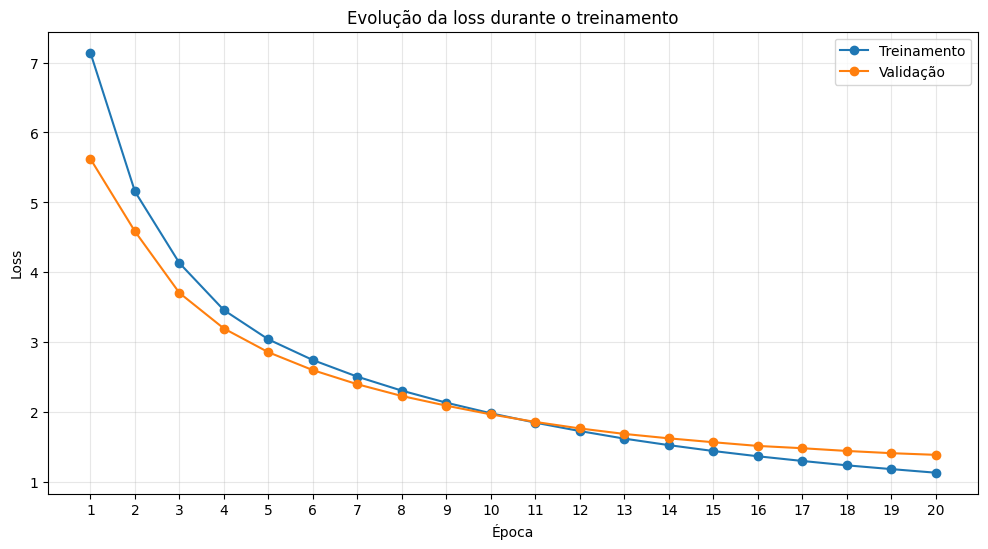

In [36]:
# =============================================================================
# Gráfico da evolução do treinamento e da validação
# =============================================================================

historico_treinamento = pd.DataFrame(
    history.history
)

historico_treinamento["epoch"] = range(
    1,
    len(historico_treinamento) + 1
)

plt.figure(figsize=(12, 6))

plt.plot(
    historico_treinamento["epoch"],
    historico_treinamento["loss"],
    marker="o",
    label="Treinamento"
)

plt.plot(
    historico_treinamento["epoch"],
    historico_treinamento["val_loss"],
    marker="o",
    label="Validação"
)

plt.title(
    "Evolução da loss durante o treinamento"
)

plt.xlabel(
    "Época"
)

plt.ylabel(
    "Loss"
)

plt.xticks(
    historico_treinamento["epoch"]
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.show()

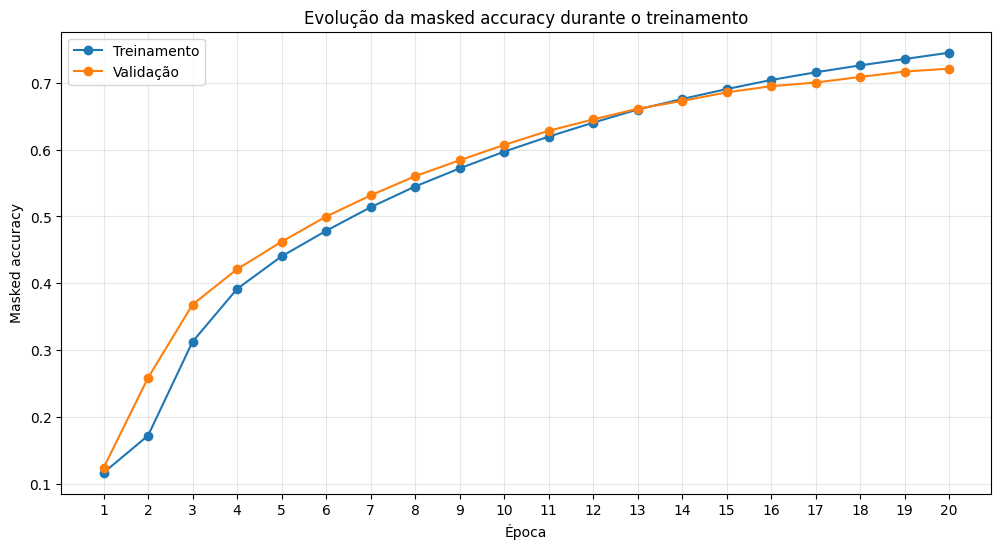

In [37]:
# =============================================================================
# Gráfico da evolução da acurácia mascarada
# =============================================================================

plt.figure(figsize=(12, 6))

plt.plot(
    historico_treinamento["epoch"],
    historico_treinamento["masked_accuracy"],
    marker="o",
    label="Treinamento"
)

plt.plot(
    historico_treinamento["epoch"],
    historico_treinamento["val_masked_accuracy"],
    marker="o",
    label="Validação"
)

plt.title(
    "Evolução da masked accuracy durante o treinamento"
)

plt.xlabel(
    "Época"
)

plt.ylabel(
    "Masked accuracy"
)

plt.xticks(
    historico_treinamento["epoch"]
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.show()

### Utilizando o transformer para tradução de algumas frases

In [31]:
# =============================================================================
# Predição de traduções com geração gulosa
# =============================================================================

def preparar_entrada_encoder_para_predicao(texto_source):
    """
    Tokeniza uma frase em inglês para entrada do encoder.

    O BertTokenizerFast adiciona automaticamente:
    - [CLS] no início;
    - [SEP] no final.
    """
    tokenizado = tokenizer(
        [texto_source],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN_SOURCE,
        return_attention_mask=True,
        return_token_type_ids=True
    )

    encoder_input_ids = tf.constant(
        tokenizado["input_ids"],
        dtype=tf.int32
    )

    encoder_padding_mask = tf.constant(
        tokenizado["attention_mask"],
        dtype=tf.int32
    )

    encoder_segment_ids = tf.constant(
        tokenizado["token_type_ids"],
        dtype=tf.int32
    )

    return encoder_input_ids, encoder_padding_mask, encoder_segment_ids


def preparar_decoder_input_para_predicao(ids_gerados):
    """
    Prepara a sequência atual do decoder com padding até MAX_LEN_TARGET.
    """
    ids_decoder = ids_gerados[:MAX_LEN_TARGET]

    padding_necessario = MAX_LEN_TARGET - len(ids_decoder)

    ids_decoder = ids_decoder + ([PAD_ID] * padding_necessario)

    decoder_input_ids = tf.constant(
        [ids_decoder],
        dtype=tf.int32
    )

    decoder_padding_mask = tf.cast(
        tf.not_equal(
            decoder_input_ids,
            PAD_ID
        ),
        dtype=tf.int32
    )

    return decoder_input_ids, decoder_padding_mask


def traduzir_frase_gulosa(texto_source):
    """
    Traduz uma frase em inglês para português usando geração gulosa.

    A geração começa com [CLS] e termina quando o modelo gera [SEP]
    ou quando o tamanho máximo da sequência é atingido.
    """
    encoder_input_ids, encoder_padding_mask, encoder_segment_ids = (
        preparar_entrada_encoder_para_predicao(
            texto_source
        )
    )

    ids_gerados = [
        CLS_ID
    ]

    for _ in range(MAX_LEN_TARGET - 1):
        decoder_input_ids, decoder_padding_mask = (
            preparar_decoder_input_para_predicao(
                ids_gerados
            )
        )

        entradas = {
            "encoder_input_ids": encoder_input_ids,
            "decoder_input_ids": decoder_input_ids,
            "encoder_padding_mask": encoder_padding_mask,
            "decoder_padding_mask": decoder_padding_mask,
            "encoder_segment_ids": encoder_segment_ids
        }

        logits = translation_model(
            entradas,
            training=False
        )

        indice_proximo_token = len(ids_gerados) - 1

        logits_proximo_token = logits[
            0,
            indice_proximo_token,
            :
        ]

        proximo_token_id = int(
            tf.argmax(
                logits_proximo_token,
                axis=-1
            ).numpy()
        )

        if proximo_token_id == SEP_ID:
            break

        ids_gerados.append(
            proximo_token_id
        )

    ids_traducao = [
        token_id
        for token_id in ids_gerados
        if token_id not in [
            CLS_ID,
            SEP_ID,
            PAD_ID
        ]
    ]

    texto_traduzido = tokenizer.decode(
        ids_traducao,
        skip_special_tokens=True
    )

    return texto_traduzido


def imprimir_traducoes(frases_source):
    """
    Imprime as traduções geradas para uma lista de frases em inglês.
    """
    for indice, frase_source in enumerate(frases_source, start=1):
        frase_traduzida = traduzir_frase_gulosa(
            frase_source
        )

        print("=" * 100)
        print(f"Exemplo {indice}")
        print("Inglês:    ", frase_source)
        print("Português:", frase_traduzida)


frases_para_traduzir = [
    "Tom doesn't eat junk food anymore.",
    "This is my room.",
    "We must deal with this problem.",
    "I have some great news.",
    "You have no idea how much that means to me."
]

imprimir_traducoes(
    frases_para_traduzir
)

Exemplo 1
Inglês:     Tom doesn't eat junk food anymore.
Português: Tom não come mais de polícia.
Exemplo 2
Inglês:     This is my room.
Português: Este é o meu quarto.
Exemplo 3
Inglês:     We must deal with this problem.
Português: Nós devemos com isso com isso problema.
Exemplo 4
Inglês:     I have some great news.
Português: Eu tenho algumas razícias.
Exemplo 5
Inglês:     You have no idea how much that means to me.
Português: Você não tem ideia de como que eu gosta de mim.


### Verificando algumas frases traduzidas do conjunto de teste

In [29]:
# =============================================================================
# Predição de traduções em exemplos do conjunto de teste
# =============================================================================

def obter_texto_source_target(par):
    """
    Extrai source e target de um par do dataset.
    """
    texto_source = par[0]
    texto_target = par[1]

    return texto_source, texto_target


def imprimir_traducoes_com_referencia(pares, quantidade=5):
    """
    Gera traduções para exemplos do conjunto informado e compara com a
    tradução esperada.
    """
    pares_avaliacao = pares[:quantidade]

    for indice, par in enumerate(pares_avaliacao, start=1):
        texto_source, texto_target = obter_texto_source_target(par)

        texto_predito = traduzir_frase_gulosa(
            texto_source
        )

        print("=" * 100)
        print(f"Exemplo {indice}")
        print("Inglês:              ", texto_source)
        print("Português esperado:  ", texto_target)
        print("Português gerado:    ", texto_predito)


imprimir_traducoes_com_referencia(
    test_pares,
    quantidade=5
)

Exemplo 1
Inglês:               Why are they here?
Português esperado:   Por que elas estão aqui?
Português gerado:     Por que eles estão aqui?
Exemplo 2
Inglês:               I want to hear from Tom.
Português esperado:   Quero ouvir de Tom.
Português gerado:     Eu quero ouvir o Tom.
Exemplo 3
Inglês:               I really liked that movie.
Português esperado:   Eu gostei muito daquele filme.
Português gerado:     Eu gostava de gostava de filme.
Exemplo 4
Inglês:               He was given the finest education that money could buy.
Português esperado:   A ele foi dada a melhor educação que o dinheiro podia comprar.
Português gerado:     Ele foi a porta ponta de dinheiro que poderia comprar.
Exemplo 5
Inglês:               Why are we poor?
Português esperado:   Por que nós somos pobres?
Português gerado:     Por que nós estamos pobre?


### Salvando o modelo e o encoder

In [32]:
# =============================================================================
# Constantes de salvamento
# =============================================================================

MODEL_EXPORT_DIR = "atividade5-modelos"

TRANSLATION_MODEL_EXPORT_PATH = os.path.join(
    MODEL_EXPORT_DIR,
    "transformer_en_pt_savedmodel"
)

ENCODER_MODEL_EXPORT_PATH = os.path.join(
    MODEL_EXPORT_DIR,
    "encoder_en_savedmodel"
)

TRANSLATION_WEIGHTS_PATH = os.path.join(
    MODEL_EXPORT_DIR,
    "transformer_en_pt.weights.h5"
)

ENCODER_WEIGHTS_PATH = os.path.join(
    MODEL_EXPORT_DIR,
    "encoder_en.weights.h5"
)

In [33]:
# =============================================================================
# Salvamento do modelo completo e do encoder
# =============================================================================

class EncoderTraducao(Model):
    """
    Encoder isolado do Transformer de tradução.

    Reutiliza:
    - embedding do encoder;
    - camadas encoder treinadas no modelo de tradução.
    """

    def __init__(
        self,
        encoder_embedding,
        encoder_layers,
        name="encoder_en"
    ):
        super().__init__(
            name=name
        )

        self.encoder_embedding = encoder_embedding
        self.encoder_layers = encoder_layers

    def call(
        self,
        inputs,
        training=False
    ):
        encoder_input_ids = inputs["encoder_input_ids"]
        encoder_padding_mask = inputs["encoder_padding_mask"]

        encoder_output = self.encoder_embedding(
            encoder_input_ids,
            training=training
        )

        for encoder_layer in self.encoder_layers:
            encoder_output = encoder_layer(
                encoder_output,
                padding_mask=encoder_padding_mask,
                training=training
            )

        return encoder_output


os.makedirs(
    MODEL_EXPORT_DIR,
    exist_ok=True
)

encoder_model = EncoderTraducao(
    encoder_embedding=translation_model.encoder_embedding,
    encoder_layers=translation_model.encoder_layers,
    name="encoder_en"
)


for entradas_batch, decoder_target_batch in train_tokenized_examples.take(1):
    _ = translation_model(
        entradas_batch,
        training=False
    )

    encoder_inputs_batch = {
        "encoder_input_ids": entradas_batch["encoder_input_ids"],
        "encoder_padding_mask": entradas_batch["encoder_padding_mask"]
    }

    _ = encoder_model(
        encoder_inputs_batch,
        training=False
    )


translation_model.save_weights(
    TRANSLATION_WEIGHTS_PATH
)

encoder_model.save_weights(
    ENCODER_WEIGHTS_PATH
)


tf.saved_model.save(
    translation_model,
    TRANSLATION_MODEL_EXPORT_PATH
)

tf.saved_model.save(
    encoder_model,
    ENCODER_MODEL_EXPORT_PATH
)


print("Artefatos salvos com sucesso.")
print()
print("Modelo completo:")
print(TRANSLATION_MODEL_EXPORT_PATH)
print()
print("Pesos do modelo completo:")
print(TRANSLATION_WEIGHTS_PATH)
print()
print("Encoder:")
print(ENCODER_MODEL_EXPORT_PATH)
print()
print("Pesos do encoder:")
print(ENCODER_WEIGHTS_PATH)

INFO:tensorflow:Assets written to: atividade5-modelos/transformer_en_pt_savedmodel/assets


INFO:tensorflow:Assets written to: atividade5-modelos/transformer_en_pt_savedmodel/assets


INFO:tensorflow:Assets written to: atividade5-modelos/encoder_en_savedmodel/assets


INFO:tensorflow:Assets written to: atividade5-modelos/encoder_en_savedmodel/assets


Artefatos salvos com sucesso.

Modelo completo:
atividade5-modelos/transformer_en_pt_savedmodel

Pesos do modelo completo:
atividade5-modelos/transformer_en_pt.weights.h5

Encoder:
atividade5-modelos/encoder_en_savedmodel

Pesos do encoder:
atividade5-modelos/encoder_en.weights.h5
